<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 161.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 142.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [43]:
!pip install matplotlib
!pip install seaborn

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [22]:
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [23]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [46]:
# Checking duplicated count and rows
duplicate_count = df.duplicated().sum()
duplicates = df[df.duplicated(keep=False)]

print(f"Number of duplicated rows: {duplicate_count}")
duplicates.head()

# Remove duplicates by default keep the first occurrence and removes subsequent identical rows
df_clean = df.drop_duplicates()

Number of duplicated rows: 10

### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [47]:
# Checking missing values in CodingActivities
coding_activities_missing_values = df_clean["CodingActivities"].isnull().sum()
print(f"Number of missing values in CodingActivities: {coding_activities_missing_values}")

Number of missing values in CodingActivities: 10971

##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [48]:
# Inputing missing values in CodingActivities using ffill()
# ffill() takes the previous non-missing value and uses it to fill the missing value
df_clean["CodingActivities"] = df_clean["CodingActivities"].ffill()

# Verifying imputation
missing_after = df_clean["CodingActivities"].isnull().sum()
print(f"Missing values after imputation: {missing_after}")

Missing values after imputation: 0

**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


In [49]:
# For ConvertedCompYearly, I would prefer dropping the missing rows if the purpose is compensation analysis, rather than replacing missing salaries with an artificial value.
# The reason is that compensation is usually highly skewed, so mean/median imputation can distort the actual salary distribution
missing_before = df_clean["ConvertedCompYearly"].isnull().sum()
print(f"Missing values before handling: {missing_before}")

# Dropping rows with missing compensation
# .copy() is a good practice because you're creating a separate DataFrame specifically for compensation analysis
df_clean = df_clean.dropna(subset=["ConvertedCompYearly"]).copy()

# Verifying if missing values were dropped
missing_after = df_clean["ConvertedCompYearly"].isnull().sum()
print(f"Missing values after handling: {missing_after}")

Missing values before handling: 42002
Missing values after handling: 0

### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [50]:
# Finding compensation related columns
compensation_columns = [
    col for col in df_clean.columns
    if "Comp" in col and col != "AIComplex"
]

print(compensation_columns)

['CompTotal', 'ConvertedCompYearly']

##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [51]:
# The Min-Max formula is: xnormalized = (x - xmin / xmax - xmin)
min_comp = df_clean["ConvertedCompYearly"].min()
max_comp = df_clean["ConvertedCompYearly"].max()

# Min-Max scaling
df_clean["ConvertedCompYearly_MinMax"] = (
    (df_clean["ConvertedCompYearly"] - min_comp)
    / (max_comp - min_comp)
)

# Verifying the result
df_clean[["ConvertedCompYearly", "ConvertedCompYearly_MinMax"]].head()

,ConvertedCompYearly,ConvertedCompYearly_MinMax
72,7322.0,0.000450
374,30074.0,0.001850
379,91295.0,0.005616
385,53703.0,0.003303
389,110000.0,0.006766


In [52]:
# Verifying the ConvertedCompYearly_MinMax range
print("Minimum:", df_clean["ConvertedCompYearly_MinMax"].min())
print("Maximum:", df_clean["ConvertedCompYearly_MinMax"].max())

Minimum: 0.0
Maximum: 1.0

##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [53]:
# Creating a new column ConvertedCompYearly_Zscore with z-score calculation
df_clean["ConvertedCompYearly_Zscore"] = (
    (df_clean["ConvertedCompYearly"] - df_clean["ConvertedCompYearly"].mean())
    / df_clean["ConvertedCompYearly"].std()
)

# Checking results
df_clean[
    ["ConvertedCompYearly", "ConvertedCompYearly_Zscore"]
].head()

,ConvertedCompYearly,ConvertedCompYearly_Zscore
72,7322.0,-0.422117
374,30074.0,-0.300290
379,91295.0,0.027521
385,53703.0,-0.173767
389,110000.0,0.127678


In [54]:
# Verifying the distribution
print("Mean:", df_clean["ConvertedCompYearly_Zscore"].mean())
print("Standard deviation:", df_clean["ConvertedCompYearly_Zscore"].std())

Mean: 1.8495031739435082e-17
Standard deviation: 1.0

### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


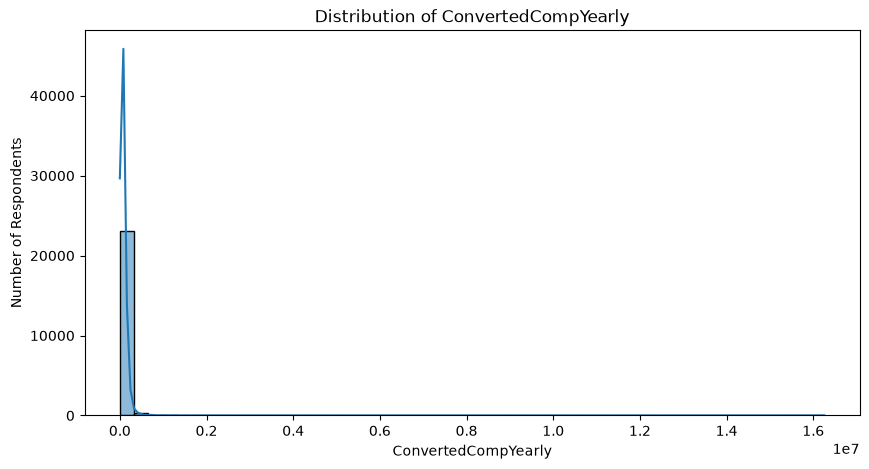

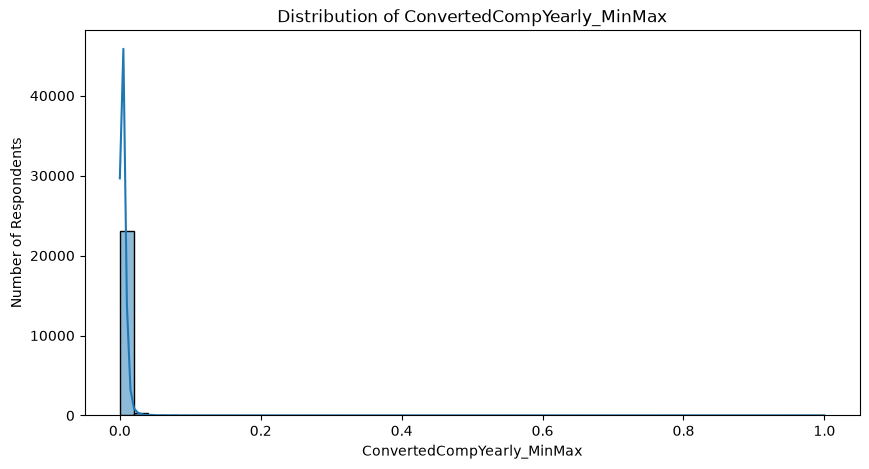

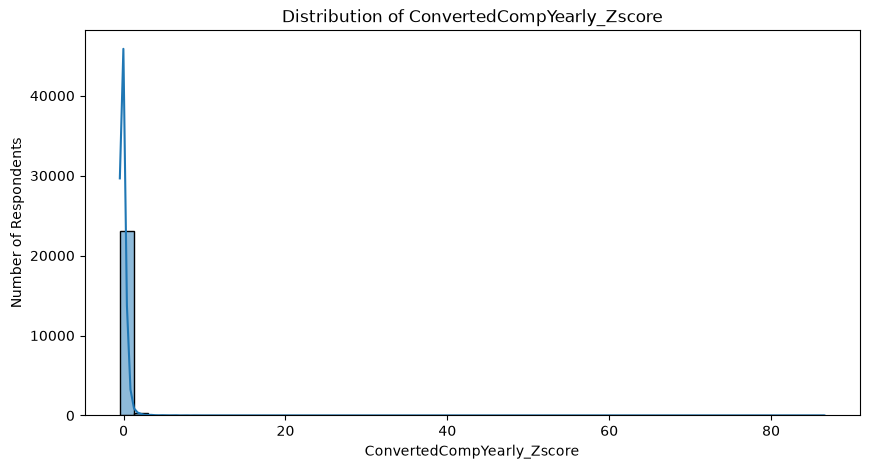

In [55]:
columns = [
    "ConvertedCompYearly",
    "ConvertedCompYearly_MinMax",
    "ConvertedCompYearly_Zscore"
]

for column in columns:
    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=df_clean,
        x=column,
        bins=50,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Respondents")

    plt.show()

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
